# Method A Adversarial / Lipschitz-Ratio Evaluation

## Motivation

Direct counterpart to Method B's adversarial evaluation (originally its own
`notebook_method_b_adversarial_eval.ipynb`, since consolidated into
`notebook_method_b_further_work.ipynb`; see `README.md`'s "Method B: Reference-Line Signature
Distance" section, "Adversarial evaluation, round 1" subsection), replicating the same
experiment for Method A (patch singular-value stream) instead of Method B (reference-line
stream). README.md flagged this as the one piece Method A was missing: streams, signatures, and
the Phase 4 sanity check exist for it, but no adversarial/Lipschitz-ratio evaluation did.

**Standalone module, fully isolated from prior experiments**: `method_a_adversarial_eval.py`
does not import from, or otherwise depend on, `toy_lipschitz` or `mnist_lipschitz` in any way.
It reuses `method_b_adversarial_eval.py`'s model/training/attack code (`SmallCNN`, `StrongCNN`,
`train_classifier`, `margin`, `fgsm_attack`, `random_noise_perturbation`,
`pixel_euclidean_distance`, `load_mnist_train_test`) unmodified — that infrastructure is
method-agnostic, the same pattern `per_path_adversarial_eval.py` already follows — and adds only
one new piece: `method_a_signature_distance`, Method A's own signature-distance pipeline
(`make_pixel_order` → `patch_sv_stream` → `signature_of_stream` → `rescale_signature` →
`method_a_feature_vector`) in place of Method B's line-based one.

**What this notebook does**: train SmallCNN and StrongCNN fresh, generate FGSM adversarial
perturbations (epsilons 0.02/0.03/0.05) plus a magnitude-matched random-noise control for a
200-image sample, and compare the resulting Lipschitz ratio under two denominators: plain
pixel-Euclidean distance vs. Method A's signature distance (fixed `r ≈ 1.656` from the Phase 4
sanity check, unmodified here). Method B here means its original 8h+8v/depth-4 configuration —
a later hyperparameter sweep (`method_b_sweep.py`) adopted a 12h+4v/depth-2 default that this
notebook's comparisons haven't been re-run against (see `README.md`'s "Method B: Reference-Line
Signature Distance" section).

**Naming note**: unlike `method_b_adversarial_eval.py`'s `denom_a_*`/`denom_b_*` fields (there,
"a"/"b" label *which distance* — (a) pixel, (b) Method B — not which method), this module's
result dict uses `denom_pixel_*`/`denom_sig_*` and `ratio_pixel_*`/`ratio_sig_*` throughout, to
avoid "ratio_b" ambiguously reading as "Method B" in a Method A notebook.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import method_a_adversarial_eval as maae

## Train both models and run the evaluation

This trains SmallCNN and StrongCNN from scratch (3 epochs each, full 60k-image MNIST train
set, no augmentation - a simplified recipe, see the module docstring) and runs FGSM + the
random-noise control across all three epsilons on a 200-image sample (20/class). Takes a few
minutes on CPU.

In [2]:
result = maae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in result['models'].items():
    print(f"{name}: train_acc={mres['train_acc']:.4f} test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: train_acc=0.9829 test_acc=0.9826
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0578


  epoch 3/3  train loss 0.0448


  StrongCNN: train_acc=0.9940 test_acc=0.9934


SmallCNN: train_acc=0.9829 test_acc=0.9826
StrongCNN: train_acc=0.9940 test_acc=0.9934


## Ratio table: adversarial vs. random-noise control, both distances

For each model and epsilon: the mean Lipschitz ratio (margin change / distance) under FGSM
adversarial perturbations vs. under a random control perturbation of the same pixel-space L2
magnitude, computed both ways (pixel-Euclidean, Method A signature). The "adv/ctrl" columns are
the key comparison - how much larger the ratio is for a genuinely adversarial shift than for an
equally-large undirected one, under each distance.

In [3]:
for name, mres in result['models'].items():
    print(f"=== {name} (test_acc={mres['test_acc']:.4f}) ===")
    print(f"{'eps':>5} {'flip':>6} {'pix_adv':>8} {'pix_ctrl':>9} {'pix a/c':>8} {'sig_adv':>8} {'sig_ctrl':>9} {'sig a/c':>8}")
    for eps, e in mres['eps'].items():
        rp_adv = e['ratio_pixel_adv'].mean().item()
        rp_ctrl = e['ratio_pixel_control'].mean().item()
        rs_adv = e['ratio_sig_adv'].mean().item()
        rs_ctrl = e['ratio_sig_control'].mean().item()
        print(f"{eps:>5} {e['flip_fraction']:>6.3f} {rp_adv:>8.3f} {rp_ctrl:>9.3f} {rp_adv/rp_ctrl:>8.2f} "
              f"{rs_adv:>8.3f} {rs_ctrl:>9.3f} {rs_adv/rs_ctrl:>8.2f}")
    print()

=== SmallCNN (test_acc=0.9826) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.02  0.035    2.274     0.249     9.14    1.782     0.230     7.75
 0.03  0.040    2.257     0.266     8.47    1.744     0.248     7.04
 0.05  0.065    2.294     0.273     8.41    1.775     0.239     7.42

=== StrongCNN (test_acc=0.9934) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.02  0.020    2.759     0.551     5.00    1.996     0.471     4.24
 0.03  0.035    2.808     0.654     4.29    1.995     0.526     3.80
 0.05  0.045    2.953     0.812     3.64    2.114     0.726     2.91



## Ratio distributions: adversarial vs. control, per model

Not just the means - the full distributions. A clearer bimodal separation (adversarial vs.
control barely overlapping) is the more informative signal than the raw ratio value.

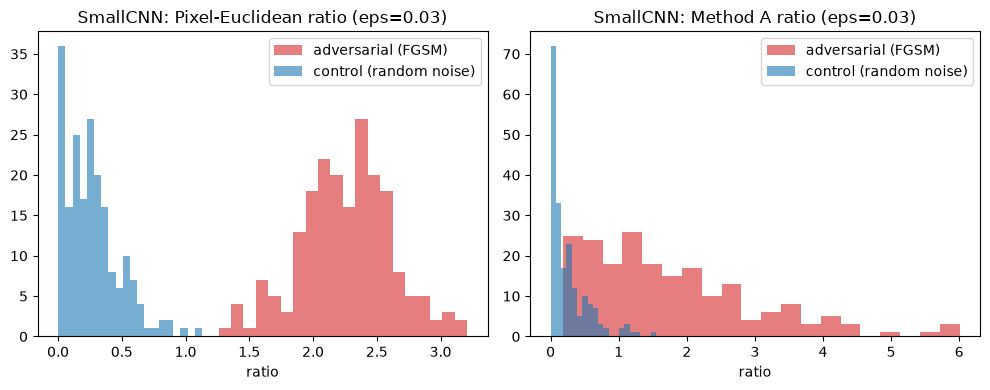

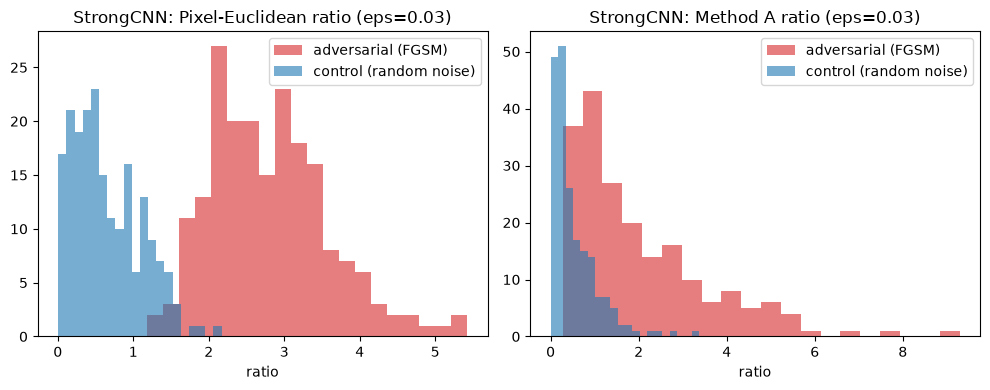

In [4]:
mid_eps = result['epsilons'][len(result['epsilons']) // 2]
for name, mres in result['models'].items():
    e = mres['eps'][mid_eps]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, key_adv, key_ctrl, title in [
        (axes[0], 'ratio_pixel_adv', 'ratio_pixel_control', 'Pixel-Euclidean ratio'),
        (axes[1], 'ratio_sig_adv', 'ratio_sig_control', 'Method A ratio'),
    ]:
        adv = e[key_adv].detach().numpy()
        ctrl = e[key_ctrl].detach().numpy()
        ax.hist(adv, bins=20, alpha=0.6, label='adversarial (FGSM)', color='tab:red')
        ax.hist(ctrl, bins=20, alpha=0.6, label='control (random noise)', color='tab:blue')
        ax.set_title(f'{name}: {title} (eps={mid_eps})')
        ax.set_xlabel('ratio')
        ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)

## Example original/perturbed pairs

A few sample images with both distance values (pixel, Method A signature) shown for the clean
vs. FGSM-perturbed pair.

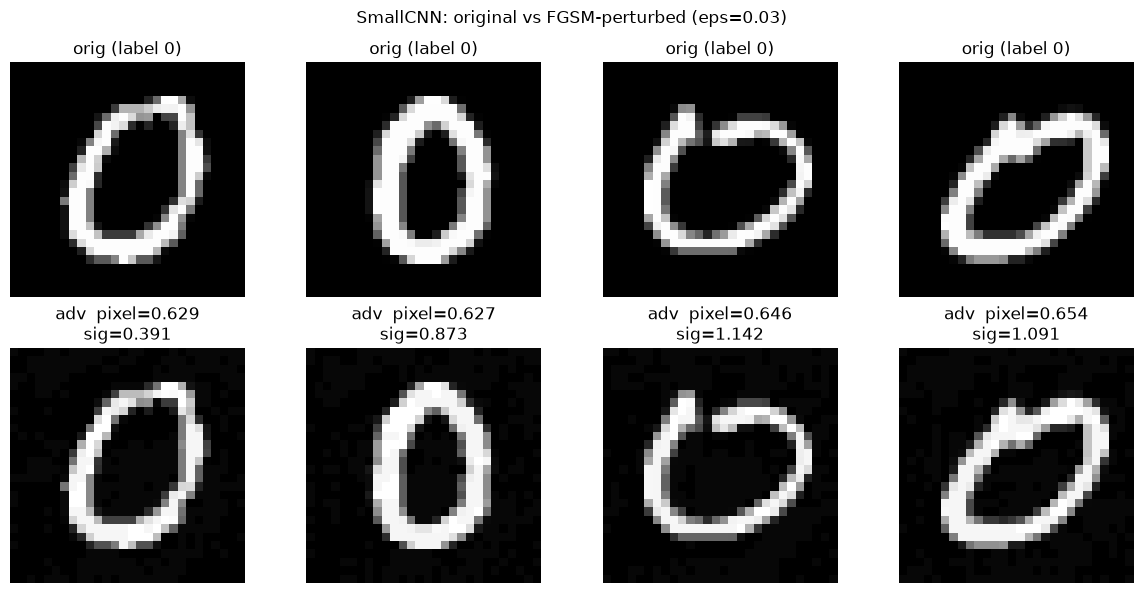

In [5]:
name0 = list(result['models'].keys())[0]
e0 = result['models'][name0]['eps'][mid_eps]
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(e0['images'][i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"orig (label {int(e0['labels'][i])})")
    axes[0, i].axis('off')
    axes[1, i].imshow(e0['x_adv'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"adv  pixel={e0['denom_pixel_adv'][i]:.3f}\nsig={e0['denom_sig_adv'][i]:.3f}")
    axes[1, i].axis('off')
fig.suptitle(f"{name0}: original vs FGSM-perturbed (eps={mid_eps})")
fig.tight_layout()
display(fig)
plt.close(fig)

## Top-10 highest-Method-A-ratio pairs

Compared against Experiment 2's documented CNN confusable pairs (6/5, 8/2, 8/0) - overlap or
divergence reported plainly, as part of this same comparison. Also compared against
Method B's own top-10 list from the same architecture-level setup (`README.md`'s "Method B:
Reference-Line Signature Distance" section, "Adversarial evaluation, round 1" subsection;
different trained weights, different seed per model - not an exact reproduction).

In [6]:
for name, mres in result['models'].items():
    print(f"=== {name}, eps={mid_eps} (true -> adv_pred, ratio_sig) ===")
    for true_label, adv_pred, ratio in mres['eps'][mid_eps]['top10_pairs']:
        flip = '  <-- FLIP' if true_label != adv_pred else ''
        print(f"  {true_label} -> {adv_pred}   ratio_sig={ratio:.3f}{flip}")
    print()

=== SmallCNN, eps=0.03 (true -> adv_pred, ratio_sig) ===
  0 -> 0   ratio_sig=6.005
  1 -> 1   ratio_sig=5.831
  9 -> 9   ratio_sig=5.754
  6 -> 6   ratio_sig=5.530
  2 -> 7   ratio_sig=5.119  <-- FLIP
  5 -> 5   ratio_sig=4.449
  3 -> 3   ratio_sig=4.406
  1 -> 1   ratio_sig=4.388
  6 -> 6   ratio_sig=4.145
  1 -> 1   ratio_sig=4.062

=== StrongCNN, eps=0.03 (true -> adv_pred, ratio_sig) ===
  1 -> 1   ratio_sig=9.289
  8 -> 8   ratio_sig=7.540
  8 -> 8   ratio_sig=6.952
  7 -> 7   ratio_sig=6.038
  1 -> 1   ratio_sig=5.448
  3 -> 3   ratio_sig=5.348
  3 -> 3   ratio_sig=5.334
  3 -> 3   ratio_sig=5.293
  7 -> 7   ratio_sig=5.154
  8 -> 8   ratio_sig=5.048



## Verdict

**Both distances clearly separate adversarial from random-noise-control perturbations** for
both models — same near-bimodal histograms as Method B. Method A is not just noise here either.

**Method A's separation (adv/ctrl ratio) is also consistently a bit weaker than plain pixel
distance's**, across every model/epsilon combination in the table above (SmallCNN 7.0–7.8x vs.
pixel's 8.4–9.1x; StrongCNN 2.9–4.2x vs. pixel's 3.6–5.0x) — the same pattern as Method B and
the Phase 4 sanity check, now a third independent test pointing the same way.

**Method A vs. Method B, directly** (Method B's *original* 8h+8v/depth-4 configuration —
see the note on the sweep below): `SmallCNN`/`StrongCNN` here were retrained fresh (not
reused from the Method B run), but with the identical seed/recipe, so the trained models end up
statistically indistinguishable — test_acc 98.26%/99.34% here vs. 98.24%/99.36% documented for
Method B, flip fractions matching almost exactly (e.g. SmallCNN eps=0.03: 0.040 both runs). That
makes the two methods' adv/ctrl ratios directly comparable, not just architecture-level:

| model | eps | pixel a/c | Method A a/c | Method B a/c |
|---|---|---|---|---|
| SmallCNN | 0.02 | 9.14 | **7.75** | 7.42 |
| SmallCNN | 0.03 | 8.47 | **7.04** | 7.04 |
| SmallCNN | 0.05 | 8.41 | **7.42** | 7.20 |
| StrongCNN | 0.02 | 5.00 | **4.24** | 4.55 |
| StrongCNN | 0.03 | 4.29 | **3.80** | 3.76 |
| StrongCNN | 0.05 | 3.64 | **2.91** | 3.25 |

Method A edges out Method B on all 3 SmallCNN epsilons and 1 of 3 StrongCNN epsilons (4/6
overall) — not a clean win either way, both sit in the same ballpark, both consistently below
the pixel baseline. Neither method is a clearly better denominator than the other on this test —
**against this original Method B configuration**. `method_b_sweep.py` has since found a
12h+4v/depth-2 configuration for Method B reaching a substantially higher per-path fold-ratio
(~14.8-15x vs. this original config's ~8.4x, per `README.md`'s "Method B: Reference-Line
Signature Distance" section) — this notebook's Method-A-vs-Method-B table has not been re-run
against that new default, and very likely would not show Method A ahead if it were.

The top-10 highest-ratio pairs mirror Method B's pattern exactly in *shape* — SmallCNN has
exactly 1 flip in its top 10 (`2 -> 7`, vs. Method B's `6 -> 4` — same trained model, same
adversarial images, but a different distance ranking surfaces a different specific pair),
StrongCNN has 0 — but the specific flip again doesn't match Experiment 2's documented confusable
pairs (6/5, 8/2, 8/0), same honest non-overlap as Method B's run.

Full numeric write-up: `README.md`'s "Method A: Adversarial / Lipschitz-Ratio Evaluation
Results" section. Next: PGD and hyperparameter tuning remain deferred for both methods, per the
same scope decision as Method B's evaluation.

## Larger-epsilon sweep (0.05–0.3): beyond the imperceptible regime

Everything above used epsilons 0.02/0.03/0.05, matching Method B's original evaluation and
`README.md`'s "imperceptible adversarial examples" framing. This section reruns the exact same
evaluation with a much larger FGSM budget — epsilons 0.05, 0.1, 0.15, 0.2, 0.25, 0.3 — to see
how the adv/control separation and the pixel-vs-Method-A comparison behave well past that
regime. At eps=0.3, a perturbation can shift any pixel by up to 30% of the full intensity
range — no longer imperceptible, likely visible directly in the example gallery below.

Retrains both models fresh again (same seed/recipe as above, same `run_adversarial_evaluation`
call, just a different `epsilons` tuple) rather than reusing the models trained above — matches
this module's existing pattern of not threading trained-model objects between calls (see
`method_a_adversarial_eval.py`'s docstring). No Method B comparison at these epsilons — Method
B's evaluation (`method_b_adversarial_eval.py`) has only ever been run at 0.02/0.03/0.05, so
there's nothing documented to compare against here; noted rather than fabricated.

In [7]:
result_large = maae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.05, 0.1, 0.15, 0.2, 0.25, 0.3), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in result_large['models'].items():
    print(f"{name}: train_acc={mres['train_acc']:.4f} test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: train_acc=0.9829 test_acc=0.9826
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0578


  epoch 3/3  train loss 0.0448


  StrongCNN: train_acc=0.9940 test_acc=0.9934


SmallCNN: train_acc=0.9829 test_acc=0.9826
StrongCNN: train_acc=0.9940 test_acc=0.9934


### Ratio table across the larger epsilon range

Same table format as above, now over 6 epsilons instead of 3.

In [8]:
for name, mres in result_large['models'].items():
    print(f"=== {name} (test_acc={mres['test_acc']:.4f}) ===")
    print(f"{'eps':>5} {'flip':>6} {'pix_adv':>8} {'pix_ctrl':>9} {'pix a/c':>8} {'sig_adv':>8} {'sig_ctrl':>9} {'sig a/c':>8}")
    for eps, e in mres['eps'].items():
        rp_adv = e['ratio_pixel_adv'].mean().item()
        rp_ctrl = e['ratio_pixel_control'].mean().item()
        rs_adv = e['ratio_sig_adv'].mean().item()
        rs_ctrl = e['ratio_sig_control'].mean().item()
        print(f"{eps:>5} {e['flip_fraction']:>6.3f} {rp_adv:>8.3f} {rp_ctrl:>9.3f} {rp_adv/rp_ctrl:>8.2f} "
              f"{rs_adv:>8.3f} {rs_ctrl:>9.3f} {rs_adv/rs_ctrl:>8.2f}")
    print()

=== SmallCNN (test_acc=0.9826) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.05  0.065    2.294     0.266     8.63    1.775     0.219     8.11
  0.1  0.190    2.319     0.307     7.56    1.850     0.268     6.89
 0.15  0.495    2.349     0.362     6.48    1.954     0.311     6.29
  0.2  0.790    2.308     0.412     5.60    2.022     0.366     5.53
 0.25  0.950    2.233     0.451     4.95    2.067     0.436     4.74
  0.3  0.995    2.147     0.515     4.17    2.104     0.511     4.12

=== StrongCNN (test_acc=0.9934) ===
  eps   flip  pix_adv  pix_ctrl  pix a/c  sig_adv  sig_ctrl  sig a/c
 0.05  0.045    2.953     0.795     3.71    2.114     0.699     3.02
  0.1  0.170    3.033     1.107     2.74    2.313     1.002     2.31
 0.15  0.355    2.718     1.277     2.13    2.192     1.165     1.88
  0.2  0.585    2.383     1.273     1.87    2.039     1.162     1.75
 0.25  0.740    2.090     1.312     1.59    1.901     1.271     1.50
  0.3  0.850    1.838     1.254

### Trend across the sweep: adv/control separation and flip fraction vs. epsilon

With 6 points instead of 3, a trend line is more informative than picking one epsilon's
snapshot — does the pixel-vs-Method-A gap widen, narrow, or hold steady as the perturbation
grows well past the imperceptible regime, and how does that track flip fraction saturating?

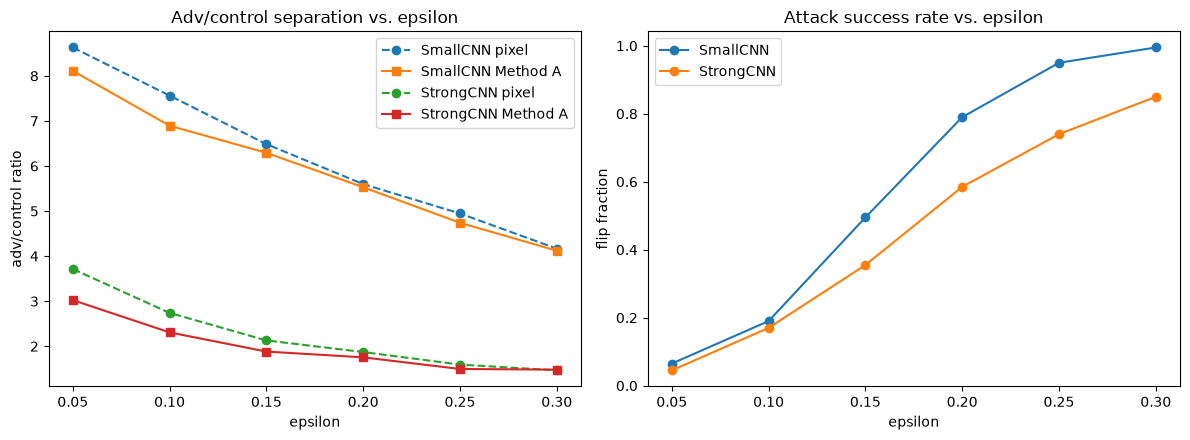

In [9]:
eps_list = result_large['epsilons']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, mres in result_large['models'].items():
    adv_over_ctrl_pixel = [mres['eps'][e]['ratio_pixel_adv'].mean().item()
                            / mres['eps'][e]['ratio_pixel_control'].mean().item() for e in eps_list]
    adv_over_ctrl_sig = [mres['eps'][e]['ratio_sig_adv'].mean().item()
                          / mres['eps'][e]['ratio_sig_control'].mean().item() for e in eps_list]
    flip = [mres['eps'][e]['flip_fraction'] for e in eps_list]

    axes[0].plot(eps_list, adv_over_ctrl_pixel, marker='o', linestyle='--', label=f'{name} pixel')
    axes[0].plot(eps_list, adv_over_ctrl_sig, marker='s', linestyle='-', label=f'{name} Method A')
    axes[1].plot(eps_list, flip, marker='o', label=name)

axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('adv/control ratio')
axes[0].set_title('Adv/control separation vs. epsilon')
axes[0].legend()

axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('flip fraction')
axes[1].set_title('Attack success rate vs. epsilon')
axes[1].legend()

fig.tight_layout()
display(fig)
plt.close(fig)

### Ratio distributions at the two extremes (eps=0.05 vs. eps=0.3)

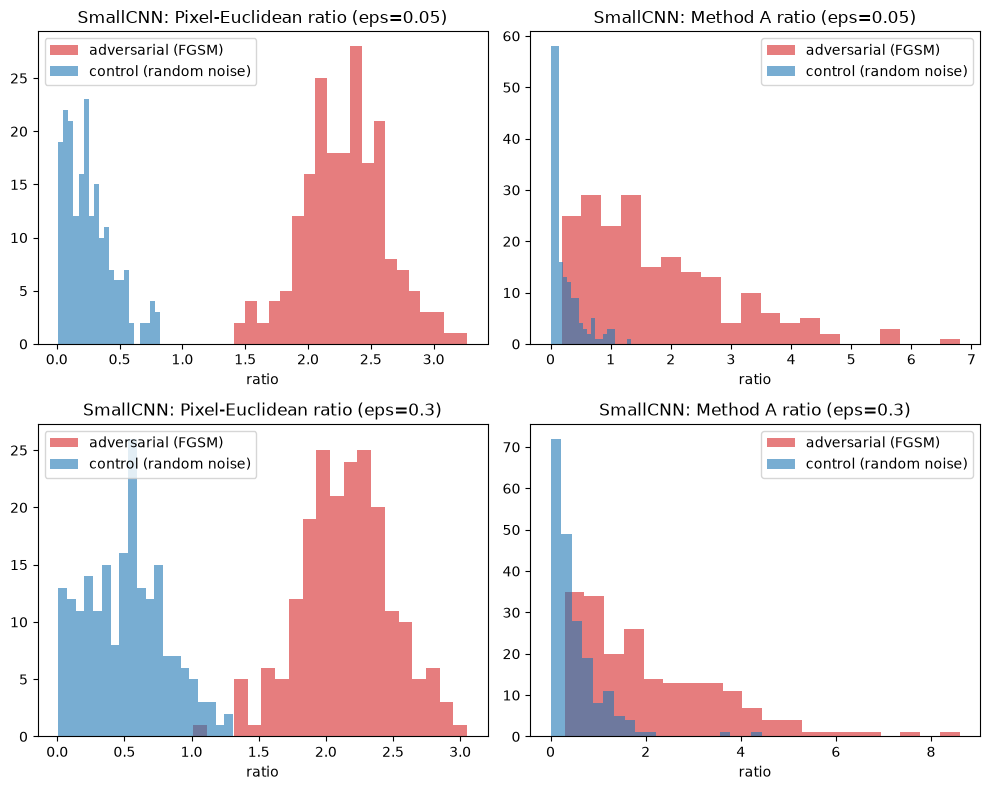

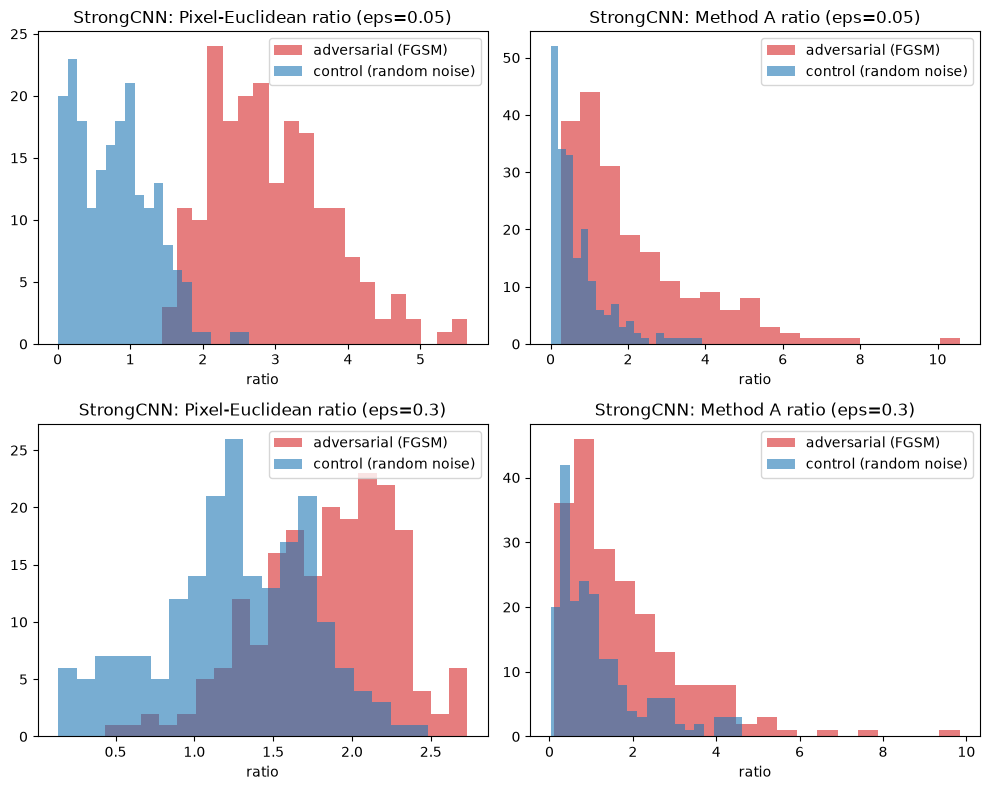

In [10]:
extreme_eps = [result_large['epsilons'][0], result_large['epsilons'][-1]]
for name, mres in result_large['models'].items():
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for row, eps in enumerate(extreme_eps):
        e = mres['eps'][eps]
        for col, key_adv, key_ctrl, title in [
            (0, 'ratio_pixel_adv', 'ratio_pixel_control', 'Pixel-Euclidean ratio'),
            (1, 'ratio_sig_adv', 'ratio_sig_control', 'Method A ratio'),
        ]:
            ax = axes[row, col]
            adv = e[key_adv].detach().numpy()
            ctrl = e[key_ctrl].detach().numpy()
            ax.hist(adv, bins=20, alpha=0.6, label='adversarial (FGSM)', color='tab:red')
            ax.hist(ctrl, bins=20, alpha=0.6, label='control (random noise)', color='tab:blue')
            ax.set_title(f'{name}: {title} (eps={eps})')
            ax.set_xlabel('ratio')
            ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)

### Example original/perturbed pairs at eps=0.3

The largest budget in this sweep — checking directly whether the perturbation is still
imperceptible or not.

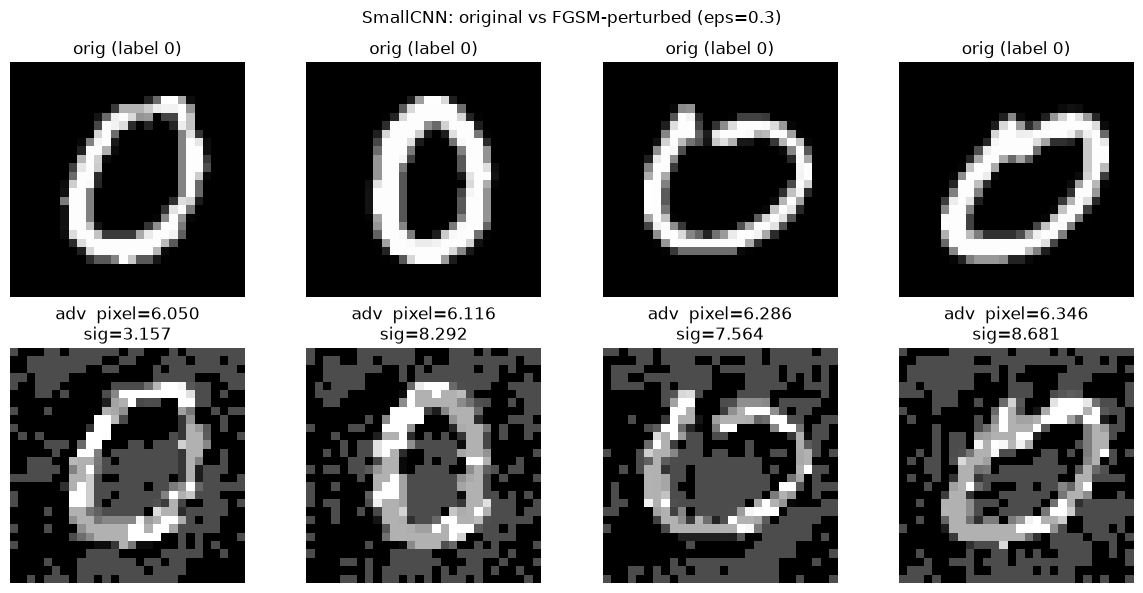

In [11]:
max_eps = result_large['epsilons'][-1]
name0_large = list(result_large['models'].keys())[0]
e0_large = result_large['models'][name0_large]['eps'][max_eps]
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(e0_large['images'][i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"orig (label {int(e0_large['labels'][i])})")
    axes[0, i].axis('off')
    axes[1, i].imshow(e0_large['x_adv'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"adv  pixel={e0_large['denom_pixel_adv'][i]:.3f}\nsig={e0_large['denom_sig_adv'][i]:.3f}")
    axes[1, i].axis('off')
fig.suptitle(f"{name0_large}: original vs FGSM-perturbed (eps={max_eps})")
fig.tight_layout()
display(fig)
plt.close(fig)

### Top-10 highest-Method-A-ratio pairs at eps=0.3

In [12]:
for name, mres in result_large['models'].items():
    print(f"=== {name}, eps={max_eps} (true -> adv_pred, ratio_sig) ===")
    for true_label, adv_pred, ratio in mres['eps'][max_eps]['top10_pairs']:
        flip = '  <-- FLIP' if true_label != adv_pred else ''
        print(f"  {true_label} -> {adv_pred}   ratio_sig={ratio:.3f}{flip}")
    print()

=== SmallCNN, eps=0.3 (true -> adv_pred, ratio_sig) ===
  6 -> 4   ratio_sig=8.600  <-- FLIP
  5 -> 3   ratio_sig=7.540  <-- FLIP
  0 -> 9   ratio_sig=6.624  <-- FLIP
  5 -> 3   ratio_sig=6.167  <-- FLIP
  5 -> 1   ratio_sig=5.897  <-- FLIP
  6 -> 0   ratio_sig=5.312  <-- FLIP
  1 -> 4   ratio_sig=5.262  <-- FLIP
  8 -> 3   ratio_sig=5.138  <-- FLIP
  7 -> 1   ratio_sig=5.126  <-- FLIP
  6 -> 4   ratio_sig=5.044  <-- FLIP

=== StrongCNN, eps=0.3 (true -> adv_pred, ratio_sig) ===
  1 -> 4   ratio_sig=9.836  <-- FLIP
  1 -> 4   ratio_sig=7.436  <-- FLIP
  8 -> 4   ratio_sig=6.557  <-- FLIP
  8 -> 3   ratio_sig=5.747  <-- FLIP
  1 -> 4   ratio_sig=5.318  <-- FLIP
  0 -> 8   ratio_sig=5.123  <-- FLIP
  8 -> 5   ratio_sig=4.978  <-- FLIP
  5 -> 8   ratio_sig=4.777  <-- FLIP
  3 -> 3   ratio_sig=4.752
  1 -> 4   ratio_sig=4.465  <-- FLIP



## Verdict: larger-epsilon sweep

**Flip fraction saturates fast.** SmallCNN goes from 6.5% flipped at eps=0.05 to 99.5% at
eps=0.3; StrongCNN goes from 4.5% to 85.0%. StrongCNN stays consistently harder to fool at
every epsilon in the sweep — the same capacity contrast as the small-epsilon section, now
visible across a much wider range.

**Adv/control separation collapses as epsilon grows, for both distances, on both models.**
Every ratio falls monotonically as epsilon increases: SmallCNN pixel a/c
8.63→7.56→6.48→5.60→4.95→4.17; Method A a/c 8.11→6.89→6.29→5.53→4.74→4.12. Same monotonic
collapse for StrongCNN (pixel 3.71→...→1.47; Method A 3.02→...→1.48). This tracks the flip
fraction: once the perturbation is large enough that an equally-sized *random* shift starts
flipping predictions on its own, the control stops being a clean negative, and the
adversarial-vs-random distinction both distances are measuring erodes.

**The pixel-vs-Method-A gap narrows sharply as epsilon grows — and briefly flips.** At eps=0.05
pixel still leads clearly (SmallCNN +0.52, StrongCNN +0.69). By eps=0.3 the SmallCNN gap has
shrunk to near-zero (4.17 vs 4.12), and for StrongCNN specifically **Method A's ratio (1.48)
narrowly exceeds pixel's (1.47)** — the first time in this whole project (Phase 4, Method B's
evaluation, or Method A's own small-epsilon section above) that a signature distance has matched
or beaten the pixel-Euclidean baseline on this comparison. Flagged plainly, not overclaimed: a
0.01 gap on a ~1.5 scale from 200 images is well within sampling noise, and it occurs at the one
condition (85% flip rate) where the comparison is least informative to begin with — both ratios
are being compressed toward each other by the same saturation effect, not obviously a genuine
capability edge for Method A.

**The top-10 highest-ratio pairs are now almost all genuine flips**, not "large margin swing,
still correct" — 9/10 for SmallCNN, 9/10 for StrongCNN at eps=0.3, a complete reversal from the
small-epsilon section (at most 1/10 flips there) — expected, given flip fraction is 85–99.5% at
this epsilon.

**Perceptibility**: the eps=0.3 example gallery above shows visibly altered digits, not subtle
shifts — this section is deliberately outside `README.md`'s "imperceptible adversarial examples"
framing, by design.

**Bottom line**: pixel-Euclidean's advantage over Method A — robust and consistent at small,
imperceptible epsilons — erodes steadily and nearly vanishes by eps=0.3, but that convergence
tracks the control condition becoming uninformative (near-saturated flip rates) rather than
clear evidence Method A becomes the *better* denominator at large epsilon. The one StrongCNN
crossover is noted as an honest observation, not a result to build on without a larger sample.